<h3>temporal pattern

<h4> Each audio feature's change over time with a line chart

In [9]:
#import cleaned data
import pandas as pd
df = pd.read_csv("data_clean.csv")

In [10]:
#check the column names
print(df.columns)

Index(['id', 'name', 'artists', 'duration_ms', 'year', 'acousticness',
       'danceability', 'energy', 'instrumentalness', 'liveness', 'loudness',
       'speechiness', 'tempo', 'valence', 'popularity', 'duration_min',
       'decade'],
      dtype='object')


In [11]:
#select the audio features needed 
features = [
    'danceability', 'energy', 'valence', 'tempo',
    'loudness', 'acousticness', 'speechiness',
    'instrumentalness', 'liveness', 'duration_min'
]

In [12]:
# Taking average group by year 
df_yearly = df.groupby('year')[features].mean().reset_index()
print(df_yearly.head())

   year  danceability    energy   valence       tempo   loudness  \
0  1921      0.436120  0.242614  0.444012  101.517303 -16.853246   
1  1922      0.480000  0.237026  0.534056  101.376139 -19.179958   
2  1923      0.568462  0.246936  0.624788  112.456598 -14.373882   
3  1924      0.550094  0.346557  0.671979  120.822238 -14.160796   
4  1925      0.571485  0.262195  0.618165  115.578840 -14.526660   

   acousticness  speechiness  instrumentalness  liveness  duration_min  
0      0.893143     0.079189          0.295576  0.212418      3.388952  
1      0.939236     0.115419          0.440470  0.238647      2.798409  
2      0.976329     0.098619          0.401932  0.236656      2.972605  
3      0.939296     0.090238          0.582639  0.238606      3.048962  
4      0.967908     0.114890          0.410437  0.243456      3.028214  


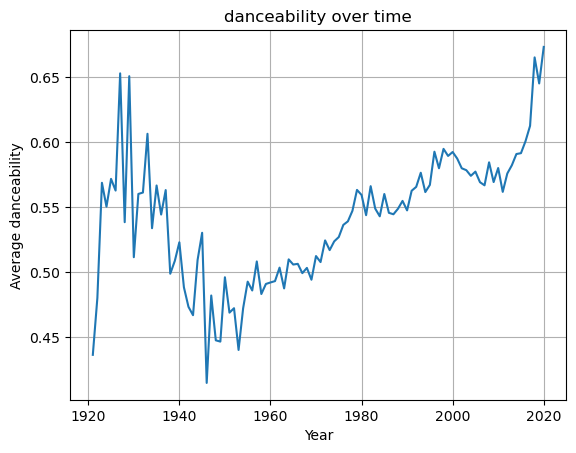

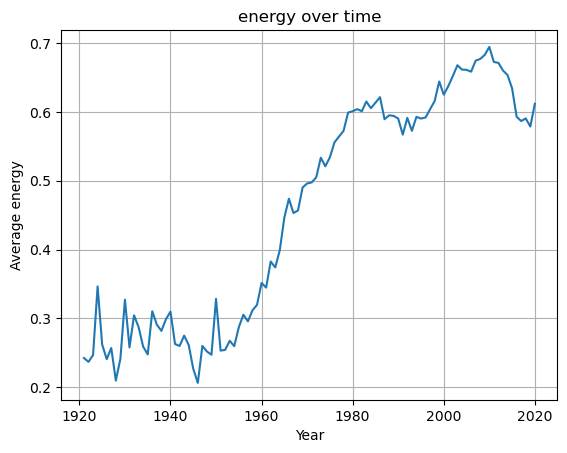

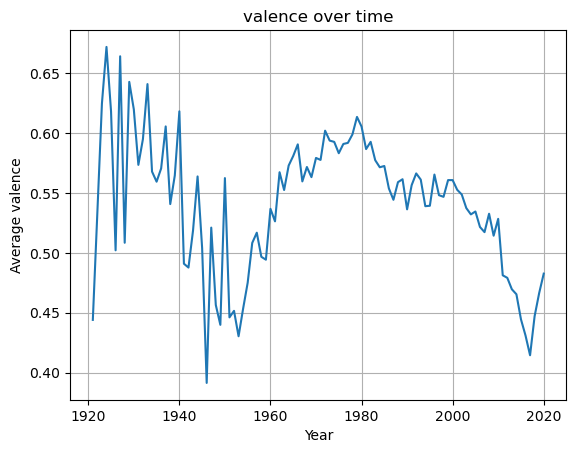

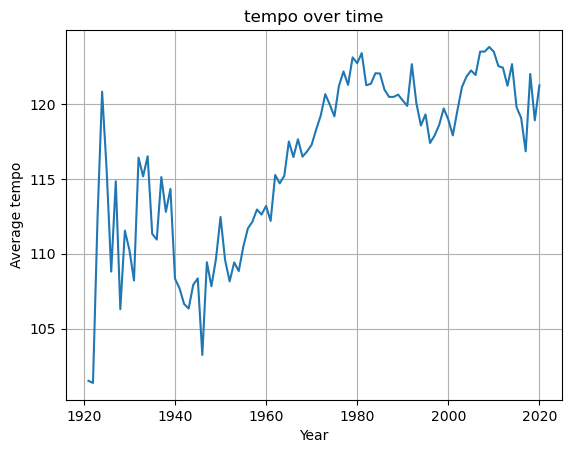

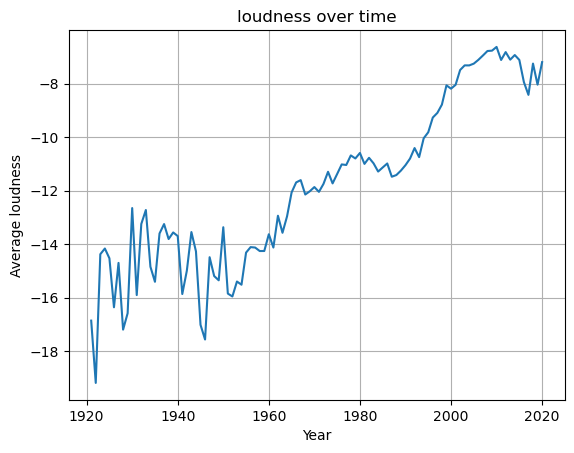

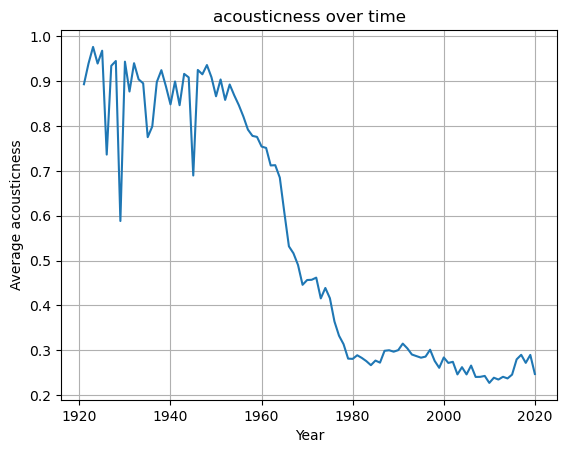

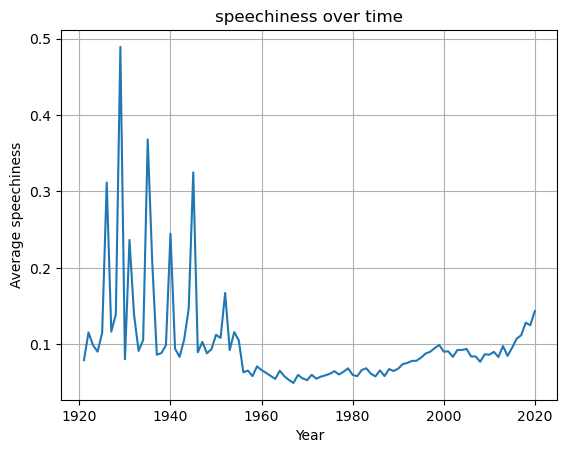

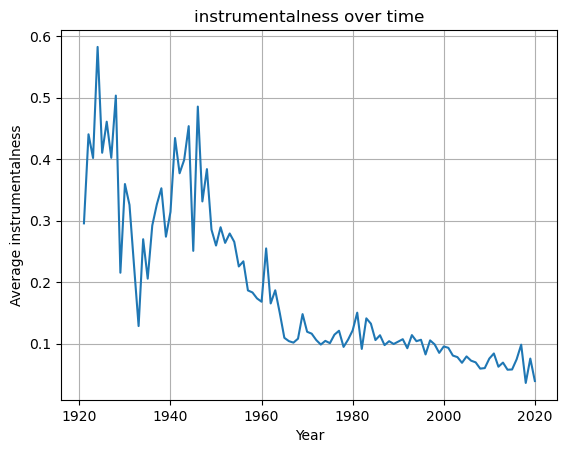

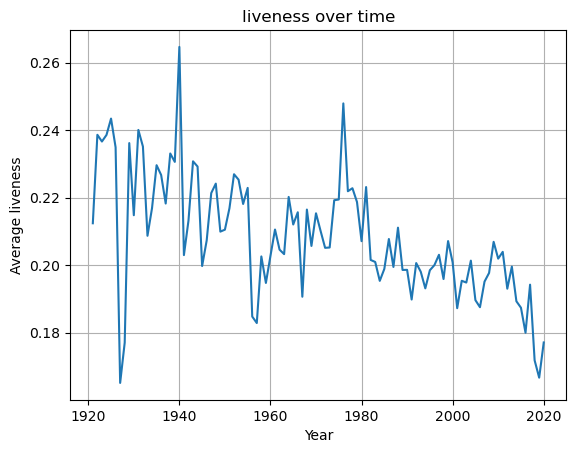

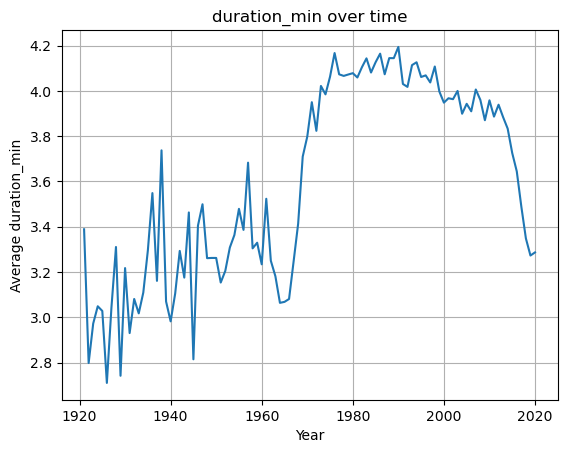

In [13]:
#plot the yearly temporal trend of audio features
import matplotlib.pyplot as plt

for feature in features:
    plt.figure()
    plt.plot(df_yearly['year'], df_yearly[feature])
    plt.title(f"{feature} over time")
    plt.xlabel("Year")
    plt.ylabel(f"Average {feature}")
    plt.grid(True)
    plt.show()

<h4>Which audio feature change the quickest</h4>

In [16]:
features = [
    'danceability', 'energy', 'valence', 'tempo',
    'loudness', 'acousticness', 'speechiness',
    'instrumentalness', 'liveness'
]

In [17]:
from sklearn.linear_model import LinearRegression
import numpy as np

trend_results = {}

for feature in features:
    X = df_yearly['year'].values.reshape(-1, 1)
    y = df_yearly[feature].values
    
    model = LinearRegression().fit(X, y)
    slope = model.coef_[0]
    
    trend_results[feature] = slope

In [18]:
import pandas as pd

pd.DataFrame(trend_results.items(), columns=["Audio Feature", "Slope"]) \
  .assign(Abs_Slope=lambda x: x["Slope"].abs()) \
  .sort_values("Abs_Slope", ascending=False) \
  .drop(columns="Abs_Slope") \
  .reset_index(drop=True)

,Audio Feature,Slope
0,tempo,0.151048
1,loudness,0.098823
2,acousticness,-0.008987
3,energy,0.005271
4,instrumentalness,-0.003750
5,danceability,0.000918
6,speechiness,-0.000791
7,valence,-0.000528
8,liveness,-0.000383


<h4>Distribution of audio features overtime (before and after 2015)</h4>

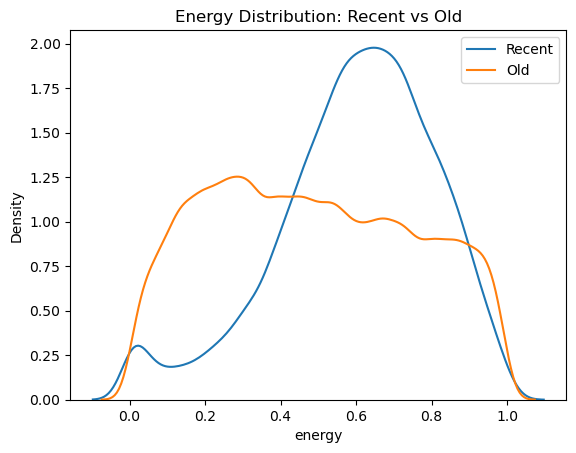

In [20]:
import seaborn as sns

sns.kdeplot(data=df[df['year'] >= 2015], x='energy', label='Recent')
sns.kdeplot(data=df[df['year'] < 2015], x='energy', label='Old')

plt.title('Energy Distribution: Recent vs Old')
plt.legend()
plt.show()

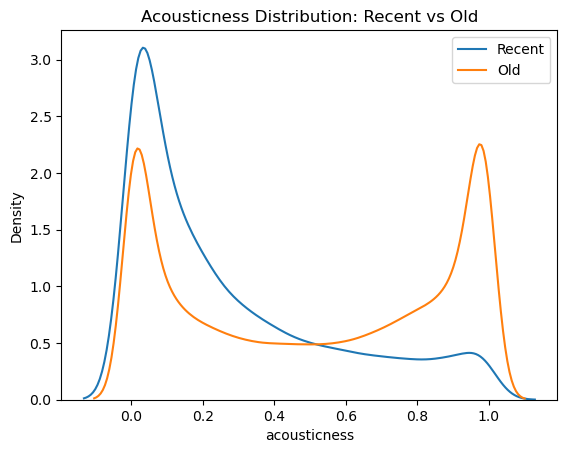

In [21]:
import seaborn as sns

sns.kdeplot(data=df[df['year'] >= 2015], x='acousticness', label='Recent')
sns.kdeplot(data=df[df['year'] < 2015], x='acousticness', label='Old')
plt.title('Acousticness Distribution: Recent vs Old')
plt.legend()
plt.show()

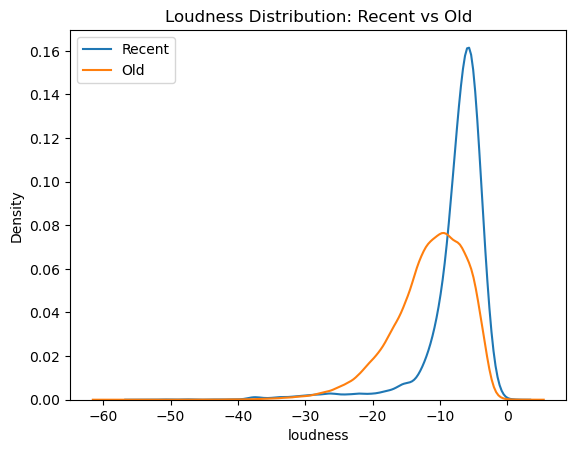

In [22]:
import seaborn as sns

sns.kdeplot(data=df[df['year'] >= 2015], x='loudness', label='Recent')
sns.kdeplot(data=df[df['year'] < 2015], x='loudness', label='Old')
plt.title('Loudness Distribution: Recent vs Old')
plt.legend()
plt.show()

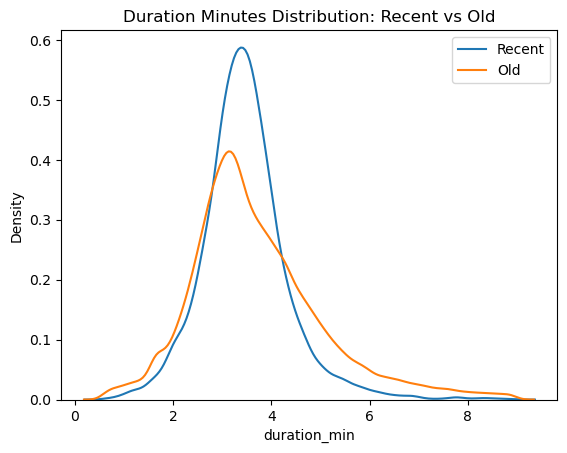

In [24]:
import seaborn as sns

sns.kdeplot(data=df[df['year'] >= 2015], x='duration_min', label='Recent')
sns.kdeplot(data=df[df['year'] < 2015], x='duration_min', label='Old')
plt.title('Duration Minutes Distribution: Recent vs Old')
plt.legend()
plt.show()

In [ ]:
以下是变化并不大的attempts

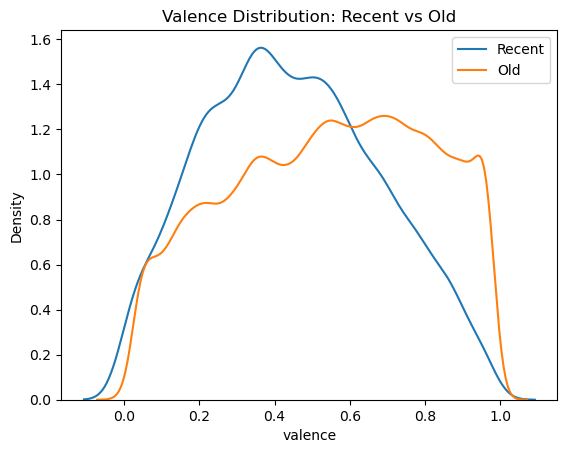

In [27]:
import seaborn as sns

sns.kdeplot(data=df[df['year'] >= 2015], x='valence', label='Recent')
sns.kdeplot(data=df[df['year'] < 2015], x='valence', label='Old')
plt.title('Valence Distribution: Recent vs Old')
plt.legend()
plt.show()

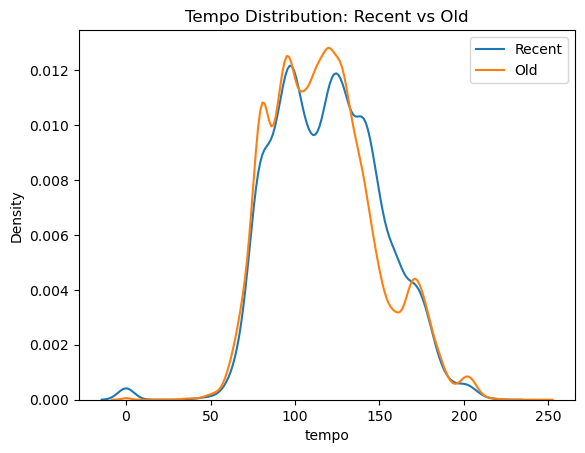

In [28]:
import seaborn as sns

sns.kdeplot(data=df[df['year'] >= 2015], x='tempo', label='Recent')
sns.kdeplot(data=df[df['year'] < 2015], x='tempo', label='Old')
plt.title('Tempo Distribution: Recent vs Old')
plt.legend()
plt.show()

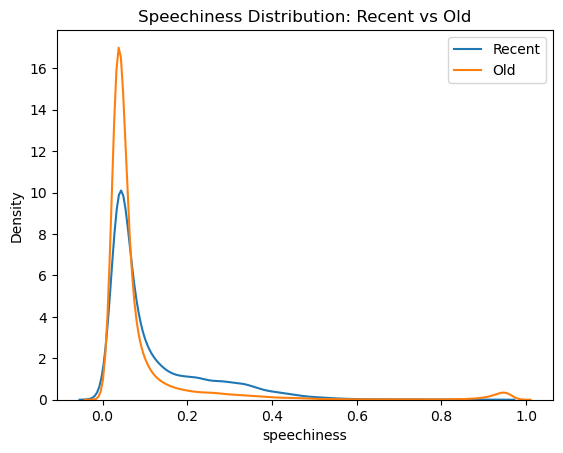

In [29]:
import seaborn as sns

sns.kdeplot(data=df[df['year'] >= 2015], x='speechiness', label='Recent')
sns.kdeplot(data=df[df['year'] < 2015], x='speechiness', label='Old')
plt.title('Speechiness Distribution: Recent vs Old')
plt.legend()
plt.show()

In [30]:
features

['danceability',
 'energy',
 'valence',
 'tempo',
 'loudness',
 'acousticness',
 'speechiness',
 'instrumentalness',
 'liveness']

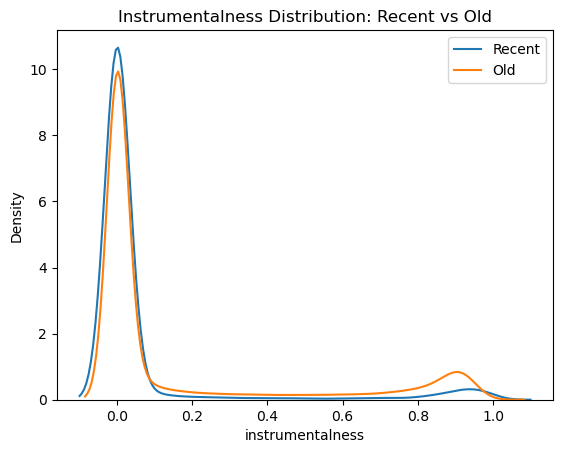

In [31]:
import seaborn as sns

sns.kdeplot(data=df[df['year'] >= 2015], x='instrumentalness', label='Recent')
sns.kdeplot(data=df[df['year'] < 2015], x='instrumentalness', label='Old')
plt.title('Instrumentalness Distribution: Recent vs Old')
plt.legend()
plt.show()

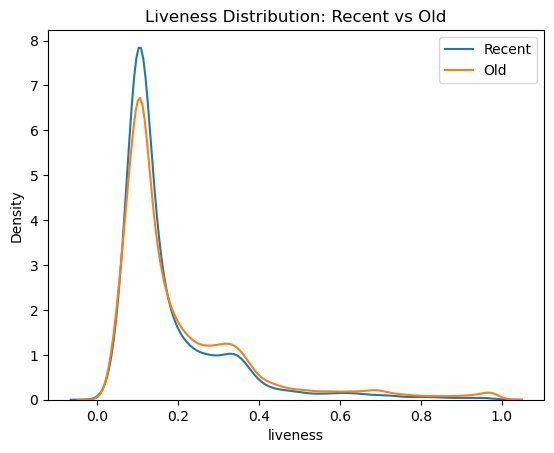

In [32]:
import seaborn as sns

sns.kdeplot(data=df[df['year'] >= 2015], x='liveness', label='Recent')
sns.kdeplot(data=df[df['year'] < 2015], x='liveness', label='Old')
plt.title('Liveness Distribution: Recent vs Old')
plt.legend()
plt.show()

<h4>Total Variance Change of Audio Features Over Time

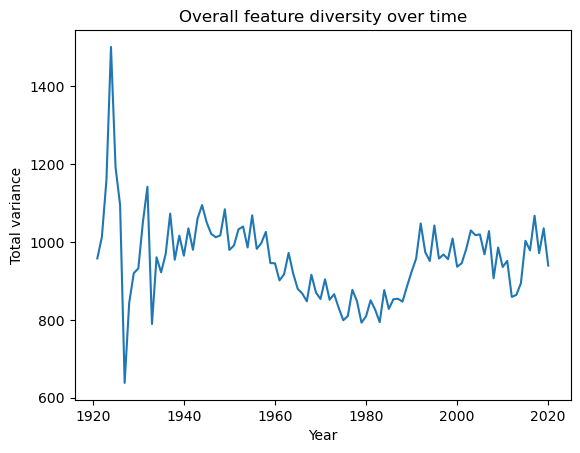

In [33]:
#sum up for the total variance plot
df_var_year = df.groupby('year')[features].var().reset_index()
df_var_year['total_variance'] = df_var_year[features].sum(axis=1)

plt.plot(df_var_year['year'], df_var_year['total_variance'])
plt.title("Overall feature diversity over time")
plt.xlabel("Year")
plt.ylabel("Total variance")
plt.show()

<h4>PCA Evaluation

In [34]:
#reduce components into 2 using PCA approach
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X = df[features]
X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
df_pca = pca.fit_transform(X_scaled)

df['PC1'] = df_pca[:,0]
df['PC2'] = df_pca[:,1]

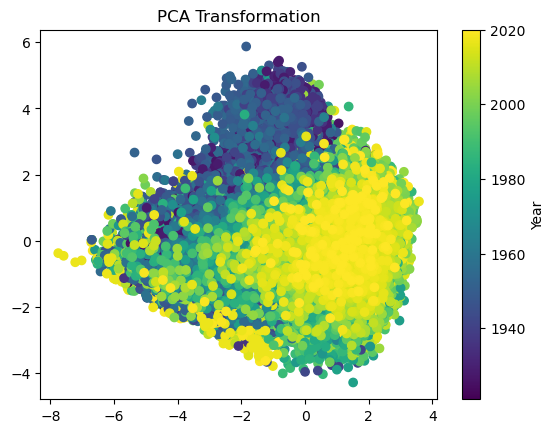

In [36]:
plt.scatter(df['PC1'], df['PC2'], c=df['year'], cmap='viridis')
plt.colorbar(label='Year')
plt.title('PCA Transformation')
plt.show()

<h4>Popularity Trend